# Retail Demand Analytics & Sales Forecasting

### Python | Pandas | SQL | Data Visualization | Machine Learning

This project analyzes retail sales and inventory data to identify sales trends, compare product and regional performance, and explore factors related to product demand. The project uses Python and SQL for data analysis and machine learning models to evaluate demand prediction.

## 1. Data Loading & Cleaning

The dataset contains retail sales, inventory, product, regional, and demand information. In this section, I load the dataset, inspect its structure, check for missing and duplicate values, and prepare the data for analysis.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/retail_store_inventory-selected-columns.csv")


In [3]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64


In [4]:
df.shape

(73100, 10)

In [5]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             73100 non-null  object 
 1   Store ID         73100 non-null  object 
 2   Product ID       73100 non-null  object 
 3   Category         73100 non-null  object 
 4   Region           73100 non-null  object 
 5   Inventory Level  73100 non-null  int64  
 6   Units Sold       73100 non-null  int64  
 7   Units Ordered    73100 non-null  int64  
 8   Demand Forecast  73100 non-null  float64
 9   Price            73100 non-null  float64
dtypes: float64(2), int64(3), object(5)
memory usage: 5.6+ MB


In [7]:
df.isnull().sum()

Date               0
Store ID           0
Product ID         0
Category           0
Region             0
Inventory Level    0
Units Sold         0
Units Ordered      0
Demand Forecast    0
Price              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Date"]= pd.to_datetime(df["Date"])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             73100 non-null  datetime64[ns]
 1   Store ID         73100 non-null  object        
 2   Product ID       73100 non-null  object        
 3   Category         73100 non-null  object        
 4   Region           73100 non-null  object        
 5   Inventory Level  73100 non-null  int64         
 6   Units Sold       73100 non-null  int64         
 7   Units Ordered    73100 non-null  int64         
 8   Demand Forecast  73100 non-null  float64       
 9   Price            73100 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(4)
memory usage: 5.6+ MB


In [11]:
df.describe()

,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2022-12-31 23:59:59.999999744,274.469877,136.464870,110.004473,141.494720,55.135108
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,32.650000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,55.050000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,77.860000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,100.000000
std,NaN,129.949514,108.919406,52.277448,109.254076,26.021945


## 2. Exploratory Data Analysis

This section explores the distribution of the data across product categories and geographic regions before examining sales performance.

In [12]:
df["Category"].value_counts()

Category
Furniture      14699
Toys           14643
Clothing       14626
Groceries      14611
Electronics    14521
Name: count, dtype: int64

In [13]:
df["Region"].value_counts()

Region
East     18349
South    18297
North    18228
West     18226
Name: count, dtype: int64

## 3. Sales & Revenue Analysis

This section analyzes sales performance across product categories and regions. Revenue is also calculated to identify which product categories generate the most value.

In [14]:
category_sales = df.groupby("Category")["Units Sold"].sum().sort_values(ascending=False)
category_sales

Category
Furniture      2025017
Groceries      2000482
Clothing       1999166
Toys           1990485
Electronics    1960432
Name: Units Sold, dtype: int64

In [15]:
region_sales = df.groupby("Region")["Units Sold"].sum().sort_values(ascending=False)
region_sales

Region
East     2511265
South    2507799
North    2484966
West     2471552
Name: Units Sold, dtype: int64

In [16]:
df["Revenue"] = df["Units Sold"] * df["Price"]

In [17]:
category_revenue = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)
category_revenue

Category
Furniture      1.115118e+08
Groceries      1.109845e+08
Clothing       1.096510e+08
Toys           1.096424e+08
Electronics    1.084391e+08
Name: Revenue, dtype: float64

In [18]:
clothing = df[df["Category"] == "Clothing"]
clothing.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Revenue
7,2022-01-01,S001,P0008,Clothing,North,380,312,54,329.73,97.99,30572.88
11,2022-01-01,S001,P0012,Clothing,West,66,24,70,26.75,58.25,1398.00
13,2022-01-01,S001,P0014,Clothing,West,193,12,187,6.80,78.11,937.32
14,2022-01-01,S001,P0015,Clothing,North,379,369,154,363.46,92.99,34313.31
17,2022-01-01,S001,P0018,Clothing,South,241,151,47,147.27,19.57,2955.07


In [19]:
clothing.groupby("Region")["Units Sold"].sum().sort_values(ascending=False)


Region
South    510882
West     509447
East     507229
North    471608
Name: Units Sold, dtype: int64

In [20]:
clothing_region_sales = clothing.groupby("Region")["Units Sold"].sum().sort_values(ascending=False)
clothing_region_sales

Region
South    510882
West     509447
East     507229
North    471608
Name: Units Sold, dtype: int64

In [21]:
import matplotlib.pyplot as plt

## 4. Data Visualization

Visualizations are used to compare sales performance across product categories and regions and to examine how retail sales change over time.

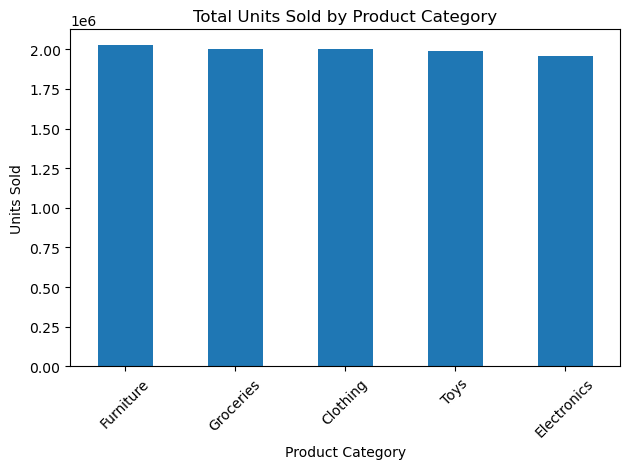

In [22]:
category_sales.plot(kind="bar")
plt.title("Total Units Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Units Sold"].sum()
monthly_sales.head()

Date
2022-01    419938
2022-02    391052
2022-03    426073
2022-04    407380
2022-05    414799
Freq: M, Name: Units Sold, dtype: int64

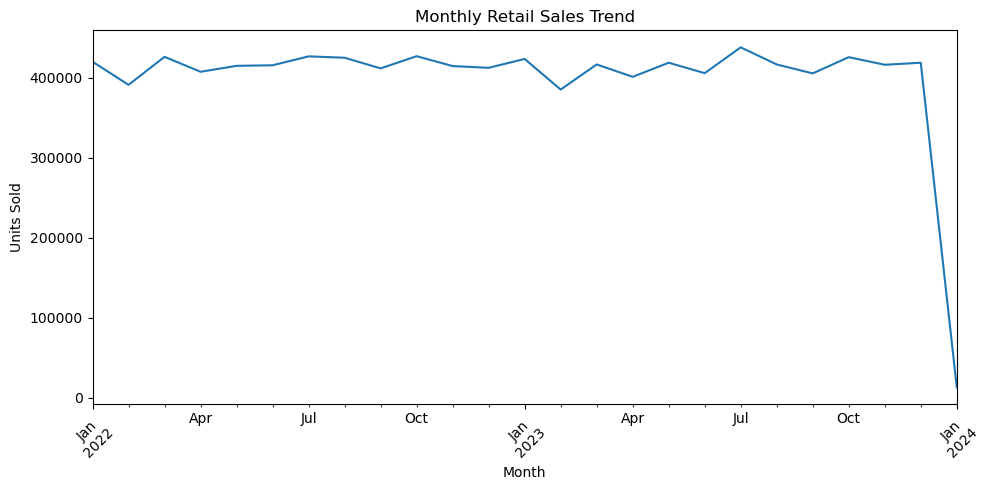

In [24]:

monthly_sales.plot(kind="line", figsize=(10,5))

plt.title("Monthly Retail Sales Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
df[["Price", "Units Sold","Demand Forecast", "Inventory Level", "Units Ordered"]].corr()

,Price,Units Sold,Demand Forecast,Inventory Level,Units Ordered
Price,1.000000,0.001082,0.000675,0.009140,0.004212
Units Sold,0.001082,1.000000,0.996853,0.589995,-0.000930
Demand Forecast,0.000675,0.996853,1.000000,0.588561,-0.001102
Inventory Level,0.009140,0.589995,0.588561,1.000000,0.001060
Units Ordered,0.004212,-0.000930,-0.001102,0.001060,1.000000


In [26]:
df["Date"].min(), df["Date"].max()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2024-01-01 00:00:00'))

In [27]:
monthly_sales.tail()

Date
2023-09    405361
2023-10    425646
2023-11    416126
2023-12    418672
2024-01     13244
Freq: M, Name: Units Sold, dtype: int64

In [28]:
complete_data = df[df["Date"] < "2024-01-01"]

monthly_sales = complete_data.groupby(
    complete_data["Date"].dt.to_period("M")
)["Units Sold"].sum()

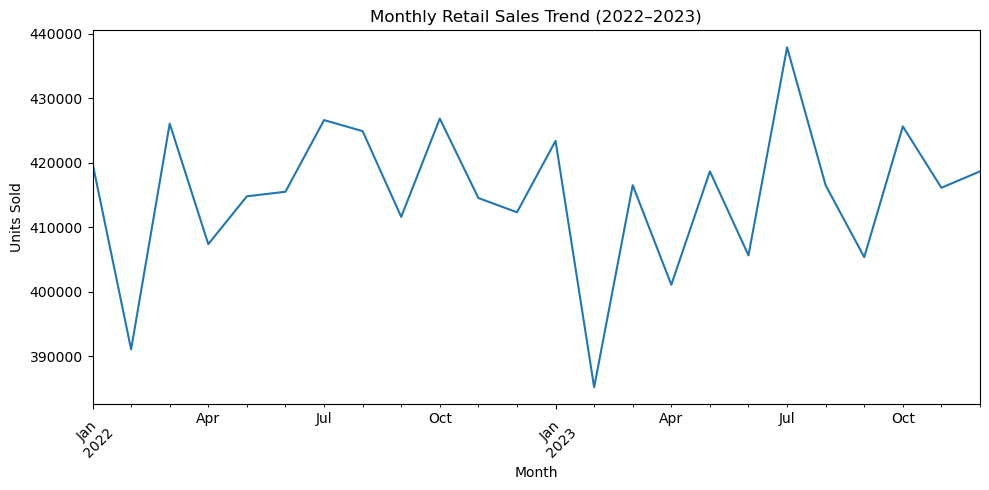

In [29]:
monthly_sales.plot(kind="line", figsize=(10,5))

plt.title("Monthly Retail Sales Trend (2022–2023)")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
import sqlite3

In [31]:
conn = sqlite3.connect("retail_sales.db")

df.to_sql("sales", conn, if_exists="replace", index=False)

73100

In [32]:
query = """
SELECT *
FROM sales
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Revenue
0,2022-01-01 00:00:00,S001,P0001,Groceries,North,231,127,55,135.47,33.50,4254.50
1,2022-01-01 00:00:00,S001,P0002,Toys,South,204,150,66,144.04,63.01,9451.50
2,2022-01-01 00:00:00,S001,P0003,Toys,West,102,65,51,74.02,27.99,1819.35
3,2022-01-01 00:00:00,S001,P0004,Toys,North,469,61,164,62.18,32.72,1995.92
4,2022-01-01 00:00:00,S001,P0005,Electronics,East,166,14,135,9.26,73.64,1030.96


## 5. SQL Analysis

SQL is used to query the retail dataset and summarize business performance. The queries examine total units sold and revenue across product categories and geographic regions.

In [33]:
query = """
SELECT Category,
       SUM("Units Sold") AS Total_Units_Sold
FROM sales
GROUP BY Category
ORDER BY Total_Units_Sold DESC;
"""

pd.read_sql_query(query, conn)

,Category,Total_Units_Sold
0,Furniture,2025017
1,Groceries,2000482
2,Clothing,1999166
3,Toys,1990485
4,Electronics,1960432


In [34]:
query = """
SELECT Region,
       SUM("Units Sold") AS Total_Units_Sold
FROM sales
GROUP BY Region
ORDER BY Total_Units_Sold DESC;
"""

pd.read_sql_query(query, conn)

,Region,Total_Units_Sold
0,East,2511265
1,South,2507799
2,North,2484966
3,West,2471552


In [35]:
query = """
SELECT Category,
       ROUND(SUM(Revenue), 2) AS Total_Revenue
FROM sales
GROUP BY Category
ORDER BY Total_Revenue DESC;
"""

pd.read_sql_query(query, conn)

,Category,Total_Revenue
0,Furniture,1.115118e+08
1,Groceries,1.109845e+08
2,Clothing,1.096510e+08
3,Toys,1.096424e+08
4,Electronics,1.084391e+08


In [36]:
query = """
SELECT Region,
       SUM("Units Sold") AS Clothing_Units_Sold,
       ROUND(SUM(Revenue), 2) AS Clothing_Revenue
FROM sales
WHERE Category = 'Clothing'
GROUP BY Region
ORDER BY Clothing_Units_Sold DESC;
"""

pd.read_sql_query(query, conn)

,Region,Clothing_Units_Sold,Clothing_Revenue
0,South,510882,27981874.94
1,West,509447,27668266.30
2,East,507229,27983105.38
3,North,471608,26017790.38


## 6. Machine Learning: Demand Prediction

Machine learning models are used to predict the number of units sold based on inventory, ordering, pricing, product category, and regional information. Linear Regression and Random Forest models are evaluated using MAE, RMSE, and R².

In [37]:
features = [
    "Inventory Level",
    "Units Ordered",
    "Price",
    "Category",
    "Region"
]

X = df[features]
y = df["Units Sold"]

In [38]:
X.head()

,Inventory Level,Units Ordered,Price,Category,Region
0,231,55,33.50,Groceries,North
1,204,66,63.01,Toys,South
2,102,51,27.99,Toys,West
3,469,164,32.72,Toys,North
4,166,135,73.64,Electronics,East


In [39]:
y.head()

0    127
1    150
2     65
3     61
4     14
Name: Units Sold, dtype: int64

In [40]:
X_encoded = pd.get_dummies(
    X,
    columns=["Category", "Region"],
    drop_first=True
)

X_encoded.head()

,Inventory Level,Units Ordered,Price,Category_Electronics,Category_Furniture,Category_Groceries,Category_Toys,Region_North,Region_South,Region_West
0,231,55,33.50,False,False,True,False,True,False,False
1,204,66,63.01,False,False,False,True,False,True,False
2,102,51,27.99,False,False,False,True,False,False,True
3,469,164,32.72,False,False,False,True,True,False,False
4,166,135,73.64,True,False,False,False,False,False,False


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

In [42]:
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 58480
Testing rows: 14620


### Linear Regression Model

A Linear Regression model is used as a baseline to predict units sold using inventory level, units ordered, price, product category, and region.

In [43]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
y_pred = linear_model.predict(X_test)

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 68.91010301689349
RMSE: 88.04169656789028
R²: 0.3453074354951362


**Model Performance:** The Linear Regression model achieved an R² score of approximately 0.35, meaning the selected features explain about 35% of the variation in units sold. This provides a baseline for comparing other prediction models.

### Random Forest Model

A Random Forest model is also tested to determine whether a more complex machine learning model can improve demand prediction.

In [46]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
rf_pred = rf_model.predict(X_test)

In [48]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 70.7399733242134
Random Forest RMSE: 91.62260971748856
Random Forest R²: 0.29096786571960487


**Model Performance:** The Random Forest model achieved an R² score of approximately 0.29. This was lower than the Linear Regression model, indicating that Random Forest did not improve prediction performance using these features.

In [49]:
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Inventory Level,0.479472
2,Price,0.228055
1,Units Ordered,0.176464
8,Region_South,0.017558
9,Region_West,0.017062
7,Region_North,0.017062
6,Category_Toys,0.016373
5,Category_Groceries,0.016268
3,Category_Electronics,0.015870
4,Category_Furniture,0.015816


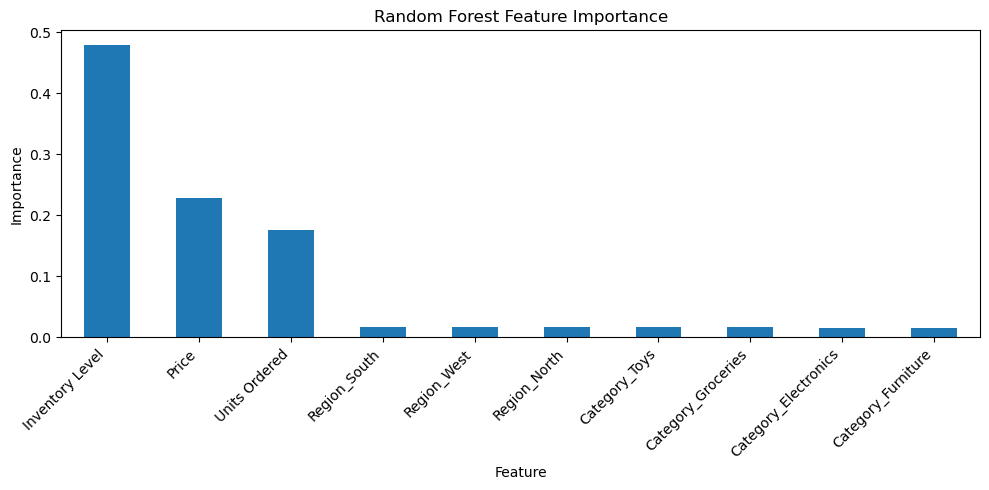

In [50]:
feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Demand Forecast Enhanced Model

The final model includes the existing Demand Forecast variable as an additional feature. This tests how much predictive performance improves when an existing demand estimate is available alongside inventory, pricing, category, and regional information.

In [51]:
features_with_forecast = [
    "Inventory Level",
    "Units Ordered",
    "Price",
    "Demand Forecast",
    "Category",
    "Region"
]

X2 = df[features_with_forecast]

X2_encoded = pd.get_dummies(
    X2,
    columns=["Category", "Region"],
    drop_first=True
)

In [52]:
X2_encoded.head()

,Inventory Level,Units Ordered,Price,Demand Forecast,Category_Electronics,Category_Furniture,Category_Groceries,Category_Toys,Region_North,Region_South,Region_West
0,231,55,33.50,135.47,False,False,True,False,True,False,False
1,204,66,63.01,144.04,False,False,False,True,False,True,False
2,102,51,27.99,74.02,False,False,False,True,False,False,True
3,469,164,32.72,62.18,False,False,False,True,True,False,False
4,166,135,73.64,9.26,True,False,False,False,False,False,False


In [53]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_encoded,
    y,
    test_size=0.20,
    random_state=42
)

In [54]:
forecast_model = LinearRegression()

forecast_model.fit(X2_train, y2_train)

forecast_pred = forecast_model.predict(X2_test)

In [55]:
forecast_mae = mean_absolute_error(y2_test, forecast_pred)
forecast_rmse = np.sqrt(mean_squared_error(y2_test, forecast_pred))
forecast_r2 = r2_score(y2_test, forecast_pred)

print("MAE:", forecast_mae)
print("RMSE:", forecast_rmse)
print("R²:", forecast_r2)

MAE: 7.417093415624553
RMSE: 8.600069433948548
R²: 0.993753100514269


**Model Interpretation:** Adding the existing Demand Forecast variable increased the model's R² from approximately 0.35 to 0.99 and reduced prediction error substantially. However, Demand Forecast was already extremely highly correlated with Units Sold (about 0.997), so this feature may contain information that makes the prediction task artificially easy. For that reason, the earlier model without Demand Forecast is treated as the more conservative baseline.

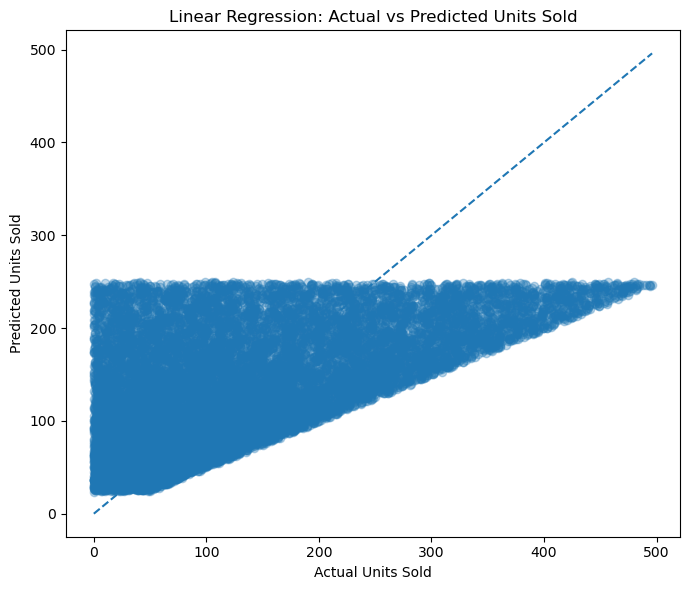

In [56]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title("Linear Regression: Actual vs Predicted Units Sold")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.tight_layout()
plt.show()

## 7. Key Findings

- Furniture had the highest total unit sales among the product categories analyzed.
- Sales volume was relatively balanced across regions and product categories.
- Inventory Level was the most influential feature in the Random Forest model.
- Linear Regression outperformed Random Forest using the baseline feature set.
- Adding Demand Forecast dramatically improved prediction performance, but its extremely high correlation with Units Sold suggests that the result should be interpreted cautiously.